# Competition https://www.kaggle.com/competitions/just-the-basics-the-after-party/overview Just the Basics - Strata 2013 After-party
## 

### All python imports

In [ ]:
# 📚 Essential Libraries
import numpy as np
import pandas as pd

# 📊 Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 🔍 Statistical Libraries
from scipy.stats import norm, skew
from scipy import stats

# ⚠️ Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 🎨 Set visualization style
sns.set(style="whitegrid")

from lightgbm import early_stopping, log_evaluation
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from xgboost import XGBRegressor
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns



print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [41]:
# Set options to prevent line breaks and expand display
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', None)      # Set a large display width
pd.set_option('display.max_colwidth', None)  # Show full content of cells (unlimited width)
pd.set_option('display.expand_frame_repr', False) # Prevent wrapping the frame representation

In [46]:
# 📥 Load datasets
train = pd.read_csv("/Users/vkdvamshi/gitRepos/ai-ml-learnings/JustTheBasics-C/train.csv" , names = [ "col_"+str(i) for i in range(100) ] )
test = pd.read_csv("/Users/vkdvamshi/gitRepos/ai-ml-learnings/JustTheBasics-C/test.csv" , names = [ "col_"+str(i) for i in range(100) ] )
train_label = pd.read_csv("/Users/vkdvamshi/gitRepos/ai-ml-learnings/JustTheBasics-C/train_labels.csv" , names=['target'] )

# 🔍 Initial exploration
print("✅ Data Loaded Successfully!")

# 🔢 Shape of datasets
print(f"📌 Training Data Shape: {train.shape}")
print(f"📌 Test Data Shape: {test.shape}")
print(f"📌 Training Labels Shape: {train_label.shape}")
print ( f"📌Training Info: {train.info()}" )
print ( f"📌Test Info: {test.info()}" )
print ( f"📌Training Labels Info: {train_label.info()}" )

print ( """describe() method gives you the statistical summary of the dataset. 
It includes measures such as count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum 
for each numerical column in the dataset. 
This information helps you understand the distribution and central tendency of the data, as well as identify any potential outliers or anomalies.

count gives you all the non-null values in the dataset. if the count is not the same for all columns then it means there are some null values in the dataset.
mean gives you the average value of the column.

Quick Data Overview: It helps you get intimate with your data quickly, providing an initial overview before deeper analysis.
Data Distribution: By looking at the mean, median (50%), min, max, and standard deviation, you can get a sense of how the data is distributed and identify potential skewness or outliers.
Spotting Data Issues: It can help check for missing values (by comparing count to the total expected entries) or unusual values.
Categorical Insights: For non-numeric data, it reveals the most common categories and the variety of entries, which is useful for understanding categorical distributions. 

Here’s what each part means:
count: Number of non-null (non-missing) entries. In this case, 5 for both columns.
mean: The average value. For Age, it’s 35. For Salary, it’s 77,000.
std (Standard Deviation): Tells you how spread out the data is. A high value means more variability.
min: The smallest value in the column.
25%, 50%, 75% (Percentiles/Quartiles):
25%: The first quartile — 25% of the data falls below this value.
50%: The median (middle value).
75%: The third quartile — 75% of the data falls below this value.
max: The highest value in the column.
.1 (10%) and .9 (90%) help you understand the distribution of extreme values.

""")
print ( f"📌Training Describe:\n {train.describe()}" )
print ( f"📌Test Describe:\n {test.describe()}" )
print ( f"📌Training Labels Describe:\n {train_label.describe()}" )

# 🔎 First look at training data
print("\n🔹 First 5 rows of Training Data:")
display(train.head())

# 🔎 First look at test data
print("\n🔹 First 5 rows of Test Data:")
display(test.head())

# Check sample values of labels 
display ( train_label.head() )


✅ Data Loaded Successfully!
📌 Training Data Shape: (600, 100)
📌 Test Data Shape: (4000, 100)
📌 Training Labels Shape: (600, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   585 non-null    float64
 1   col_1   590 non-null    float64
 2   col_2   580 non-null    float64
 3   col_3   580 non-null    float64
 4   col_4   575 non-null    float64
 5   col_5   584 non-null    float64
 6   col_6   587 non-null    float64
 7   col_7   583 non-null    float64
 8   col_8   581 non-null    float64
 9   col_9   581 non-null    float64
 10  col_10  587 non-null    float64
 11  col_11  584 non-null    float64
 12  col_12  586 non-null    float64
 13  col_13  577 non-null    float64
 14  col_14  573 non-null    float64
 15  col_15  584 non-null    float64
 16  col_16  578 non-null    float64
 17  col_17  588 non-null    float64
 18  col_18  583 non-null  

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,col_32,col_33,col_34,col_35,col_36,col_37,col_38,col_39,col_40,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52,col_53,col_54,col_55,col_56,col_57,col_58,col_59,col_60,col_61,col_62,col_63,col_64,col_65,col_66,col_67,col_68,col_69,col_70,col_71,col_72,col_73,col_74,col_75,col_76,col_77,col_78,col_79,col_80,col_81,col_82,col_83,col_84,col_85,col_86,col_87,col_88,col_89,col_90,col_91,col_92,col_93,col_94,col_95,col_96,col_97,col_98,col_99
0,0.097094,1.11330,45.038,0.88184,0.087009,1.04100,1.54860,3.49800,1.85780,0.009673,4.5162,2.4716,0.079630,4.0896,1.6902,0.91547,0.091189,1.4153,3.1192,0.006019,0.014375,0.037306,0.61815,0.055585,0.010740,3.0279,1.86360,0.014393,0.212860,2.5653,NaN,0.028234,0.040381,0.065676,0.79874,6.0681,1.348600,0.78914,0.48925,0.044965,3.6954,1.65180,NaN,2.00310,1.6097,4.25570,0.016952,1.68880,0.070763,0.028963,3.46900,0.040130,0.651000,0.076915,0.82981,2.6242,0.007722,1.9591,0.091773,0.001451,0.062135,0.097433,0.081459,0.089605,0.019517,0.39503,2.20100,3.65720,0.022237,0.042535,4.5250,0.16949,0.672310,0.052349,4.6379,0.012962,0.019132,4.5504,0.005637,0.269570,3.57430,0.040547,3.47240,0.004995,0.023048,1.9160,0.77773,0.032171,NaN,0.041627,0.076209,3.66540,0.061607,0.003161,0.036038,0.084500,2.4517,3.3373,0.065201,0.091158
1,0.050086,0.11158,94.080,1.76500,0.089417,4.80470,0.26742,NaN,0.56473,0.035123,1.4827,2.5929,0.223980,3.9993,3.4247,1.79450,0.070337,0.7135,1.1426,0.018661,0.065120,0.081132,NaN,0.060869,0.083399,2.1228,0.73517,0.096963,0.011055,3.9510,0.091110,0.018081,0.038182,0.017668,0.91469,41.0140,3.707000,2.06930,4.95710,0.016032,4.3729,3.23560,0.092688,0.22587,6.3327,2.56210,0.030500,4.17120,0.043128,1.895900,0.19076,0.049980,0.968310,0.095265,4.93420,3.6403,0.085841,2.5845,0.038742,0.000319,0.052713,0.019645,0.094237,0.036511,0.071179,0.23586,4.07320,1.24440,0.094579,0.931980,2.3565,0.82129,0.049131,0.027010,1.8648,0.011165,0.048432,0.7312,0.099694,0.168960,1.63890,2.739500,0.55716,0.070742,0.022589,1.6064,3.03450,0.063698,0.951680,0.065822,0.054712,4.16870,0.075432,0.010869,0.063972,0.079892,1.9795,3.5064,0.072132,0.091950
2,0.088447,2.36340,5.058,0.14436,0.064547,2.44400,4.25450,0.36506,1.86090,0.009759,3.5075,3.6126,0.019720,2.2723,1.1937,1.03690,0.086313,1.5003,2.3868,0.052785,0.087950,0.067695,1.46600,0.024131,0.035304,1.4450,3.83900,0.000325,0.092129,4.7438,0.033202,0.083371,0.014163,0.055091,5.06020,1.0771,0.003966,4.03610,NaN,0.019126,1.9285,0.77643,0.018482,4.57630,1.0067,1.57450,0.054700,0.34146,0.048967,0.019560,2.01550,0.072080,0.087619,0.094343,3.94530,0.5248,0.082408,1.3841,0.032529,0.024050,0.000991,0.067660,0.023938,0.090783,0.003342,2.95580,3.86110,3.76860,0.071469,0.089305,1.7302,3.76830,0.047478,0.090466,5.0165,0.088609,0.003601,1.0453,0.032310,0.090294,5.02590,0.081161,1.05090,0.015816,20.088000,1.0700,4.34680,0.061113,0.073222,0.098675,0.017203,4.56130,0.046505,NaN,0.084066,0.064829,3.3087,2.9969,0.064328,0.036793
3,0.772540,0.59469,NaN,0.97515,0.015987,0.52884,1.48840,3.96100,4.80630,0.048617,2.7212,2.5029,0.023355,4.5088,3.1327,3.86270,0.090923,4.3838,2.1928,0.026211,0.099073,0.019689,2.21980,0.042799,0.037704,4.1482,4.07180,0.017883,0.092244,3.6523,0.010751,0.055596,0.015418,0.093861,0.94272,1.0224,7.564100,2.65950,1.47560,0.772090,2.9316,1.82140,0.036775,3.85380,1.0653,NaN,0.039000,4.51470,0.088371,0.098904,4.13170,0.020435,0.364220,0.049476,0.40500,3.1788,0.040688,2.2262,0.050689,0.005585,0.087453,0.022281,0.041949,0.022086,0.008299,2.94100,0.98445,0.91658,0.050185,0.040575,1.5254,1.27960,0.014323,0.004959,0.9157,0.019139,NaN,3.4943,0.081137,0.016771,0.13016,1.063700,4.94410,0.377000,0.041079,1.5943,4.62410,0.407080,0.051634,0.057662,0.022891,0.12832,0.065028,0.036862,0.010010,0.020709,2.5237,2.1711,0.080865,0.081553
4,0.3824


🔹 First 5 rows of Test Data:


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,col_32,col_33,col_34,col_35,col_36,col_37,col_38,col_39,col_40,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52,col_53,col_54,col_55,col_56,col_57,col_58,col_59,col_60,col_61,col_62,col_63,col_64,col_65,col_66,col_67,col_68,col_69,col_70,col_71,col_72,col_73,col_74,col_75,col_76,col_77,col_78,col_79,col_80,col_81,col_82,col_83,col_84,col_85,col_86,col_87,col_88,col_89,col_90,col_91,col_92,col_93,col_94,col_95,col_96,col_97,col_98,col_99
0,0.131200,4.2014,1428.1000,2.9094,NaN,2.6650,4.54560,0.62337,4.76250,4.287300,4.1634,2.3083,0.221980,1.29720,1.4427,1.62980,0.092008,4.44820,1.0105,0.005566,0.099927,0.077645,2.59840,0.047768,0.413100,2.9789,2.37980,0.081951,0.122000,1.52090,0.104290,0.022452,0.206470,0.079903,4.0539,494.0300,1.748600,1.97080,0.39757,0.577580,2.1831,2.2359,0.061918,0.34809,6.8613,3.57230,0.013770,3.6286,0.620190,0.095503,0.15216,0.028909,0.004866,0.212350,0.2052,3.8748,0.014440,2.2396,0.071275,0.016755,0.478700,0.041618,0.014462,0.484560,0.012416,3.12480,2.2838,3.4760,0.093046,0.000145,3.47220,4.4924,0.291140,0.089994,1.02120,0.060472,0.011929,1.29450,0.092921,0.319310,2.4446,1.724700,3.01360,0.167140,0.059886,3.9036,4.75980,0.297540,1.006500,0.038641,0.099056,2.0518,0.008945,0.087689,0.070505,0.029144,1.16970,0.50162,0.045636,0.142370
1,0.083796,3.9269,80.0590,1.8780,0.064623,4.1468,3.72740,0.10988,1.90250,0.093267,0.4930,1.0429,0.087639,2.92050,3.5485,4.95760,0.014418,0.28292,3.5702,0.042867,0.063634,0.098899,2.24950,0.019954,0.091966,1.0933,1.01400,0.038756,0.377600,0.20085,0.044499,0.051952,0.041150,NaN,5.0253,16.0640,1.769100,0.95544,1.22970,1.210700,2.9946,1.1958,0.067665,0.69150,1.7052,1.41790,0.002365,4.7968,0.089561,0.643300,3.09550,0.660390,0.087505,0.047389,NaN,3.4760,0.040717,4.2748,0.073938,0.077837,0.044585,0.072703,0.014558,0.024686,0.029824,4.01810,2.9820,4.9801,0.096976,0.078579,3.40590,3.2557,0.653580,0.052675,0.80469,0.019039,0.588840,2.74470,0.011106,0.381160,3.4555,1.199400,2.31640,0.077419,0.080117,1.7493,0.63755,0.096210,0.007778,0.017614,0.046586,2.9683,0.079120,0.079630,0.026689,0.066626,1.94460,2.21630,0.099828,0.088621
2,0.067591,3.0107,25.0300,1.2643,3.031100,3.0969,1.78210,1.43460,1.88170,0.002060,3.1319,3.1005,0.095241,0.80747,1.0952,0.10468,0.000140,NaN,3.9126,0.093224,0.014574,0.020560,0.15039,0.002583,0.024998,0.7389,0.22201,0.002112,0.085670,1.73570,0.050105,0.036620,0.061289,0.012378,2.4360,5.0857,0.055347,3.30010,5.09580,0.068460,3.3671,2.1303,NaN,4.11290,1.5283,0.22106,0.041455,4.7423,0.031270,0.012651,1.29650,0.031557,3.089700,0.022964,4.5928,4.8663,NaN,2.8241,0.097391,3.129600,0.069965,0.066314,0.015224,0.088850,0.083438,0.67871,4.6017,2.5781,NaN,0.028028,2.35540,1.6424,0.024960,0.035922,4.61660,0.059600,3.056900,0.60632,0.025813,0.085994,NaN,0.058191,4.85490,0.018498,0.030039,3.6315,0.46401,0.023309,0.077759,0.049984,0.099853,1.2933,0.015907,0.061634,0.079210,0.022622,2.01960,3.44300,0.069516,0.025426
3,0.064830,0.1196,5.0957,1.9366,0.028638,1.2147,0.34675,1.11880,0.99529,0.060067,1.0770,2.7456,0.091413,4.45980,4.9004,4.21710,0.084715,2.57400,2.6175,0.069952,NaN,0.043434,2.55270,0.097121,0.006078,4.0174,1.74680,0.087326,0.040543,2.13060,0.002745,0.016619,0.011884,0.073003,4.7681,2.0322,0.074036,4.20220,5.02540,0.070365,4.8912,2.7718,0.027528,4.91680,1.2541,2.73260,0.012497,2.7828,0.060994,NaN,3.49870,0.091935,0.063803,0.039299,4.1045,1.4336,0.087976,4.1935,0.049487,0.026245,0.042097,0.040314,0.045496,0.014170,0.072185,3.63070,4.6680,2.9214,0.030039,0.066663,2.49390,3.6519,0.034071,0.016271,2.40860,0.088888,0.088306,3.45200,0.007048,0.085595,3.1218,0.067167,4.58250,0.014079,12.533000,1.4338,4.37650,0.070486,0.076038,0.057355,0.095575,4.4767,NaN,0.067340,0.054280,0.003331,0.95697,3.69700,0.049861,0.073140
4,0.345720,1.4261,44.0

,target
0,0
1,1
2,0
3,0
4,1


### Fix data

In [43]:
train.isnull().sum()

0.097094    15
1.1133      10
45.038      20
0.88184     20
0.087009    25
            ..
0.0845      17
2.4517      16
3.3373      18
0.065201    19
0.091158    26
Length: 100, dtype: int64

# Graph all the data


🔹 Missing Values in Training Data:


0.036038     29
1.6902       27
0.091158     26
0.087009     25
NaN          24
             ..
0.0014508    12
0.67231      11
1.1133       10
0.040381      9
3.0279        9
Length: 100, dtype: int64


🔹 Missing Values in Test Data:


3.4722       138
0.0089453    136
0.087689     134
0.62019      134
0.50162      133
            ... 
4.7598       103
3.9036       103
0.014462     102
2.5984       100
0.099056      98
Length: 100, dtype: int64

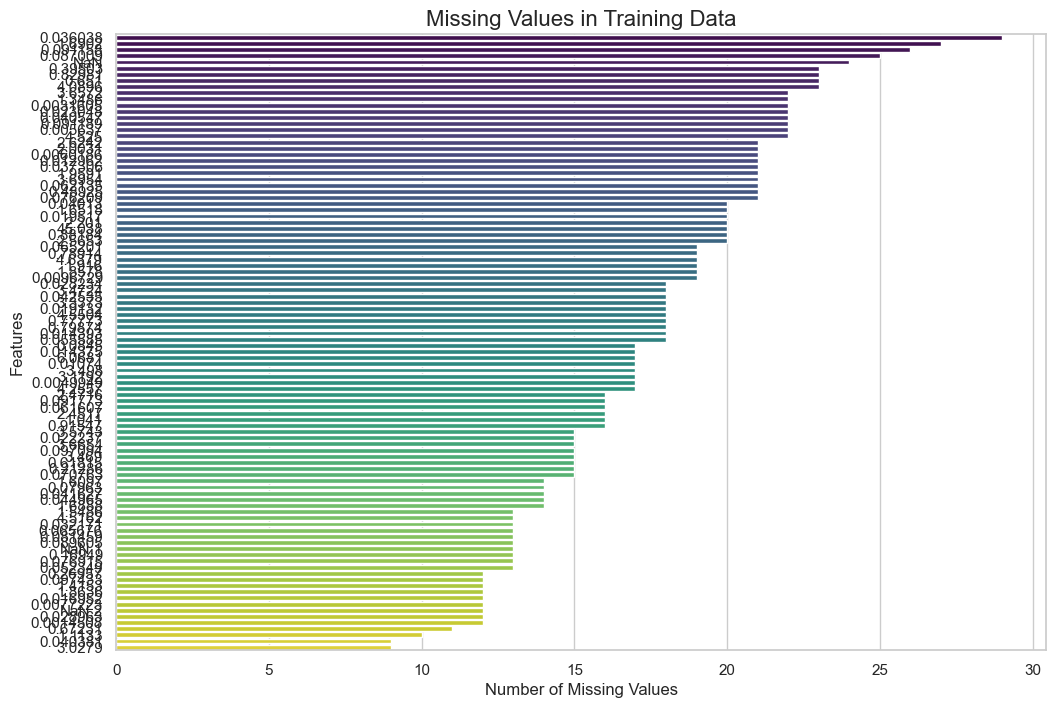

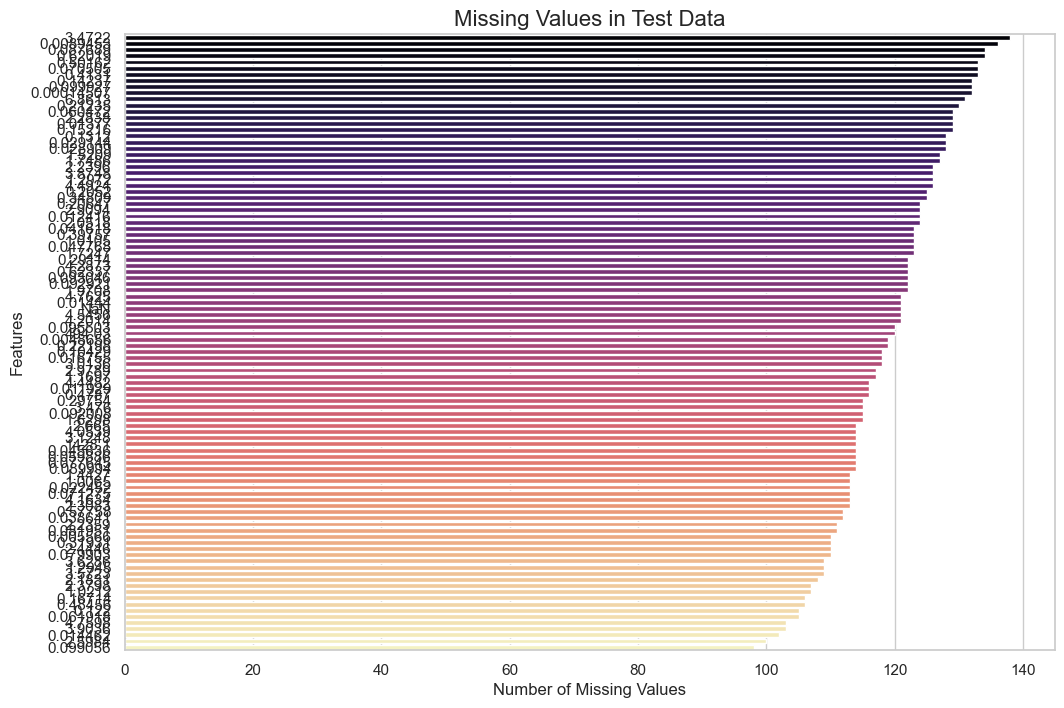

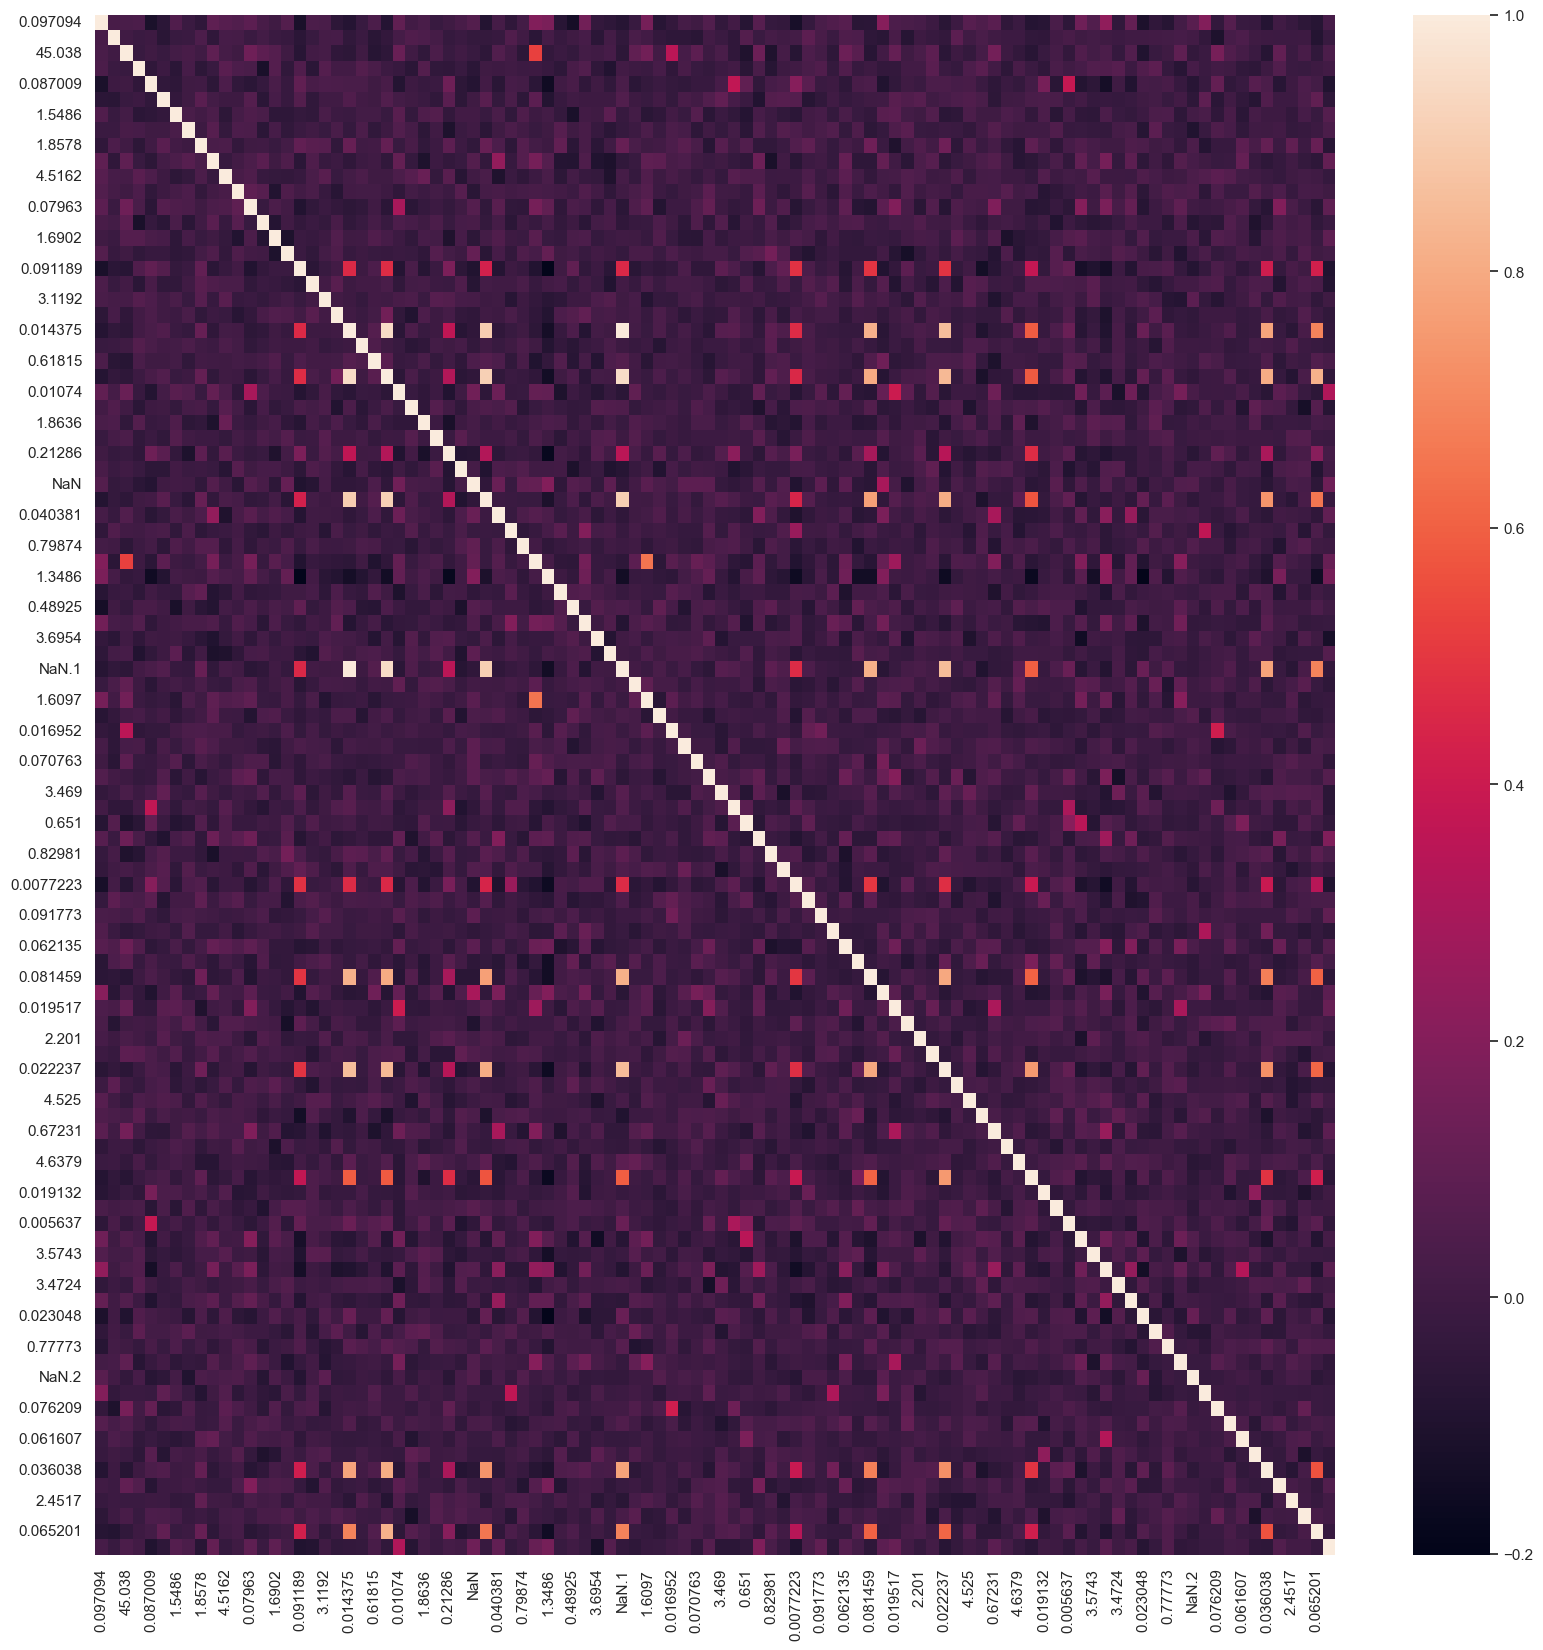

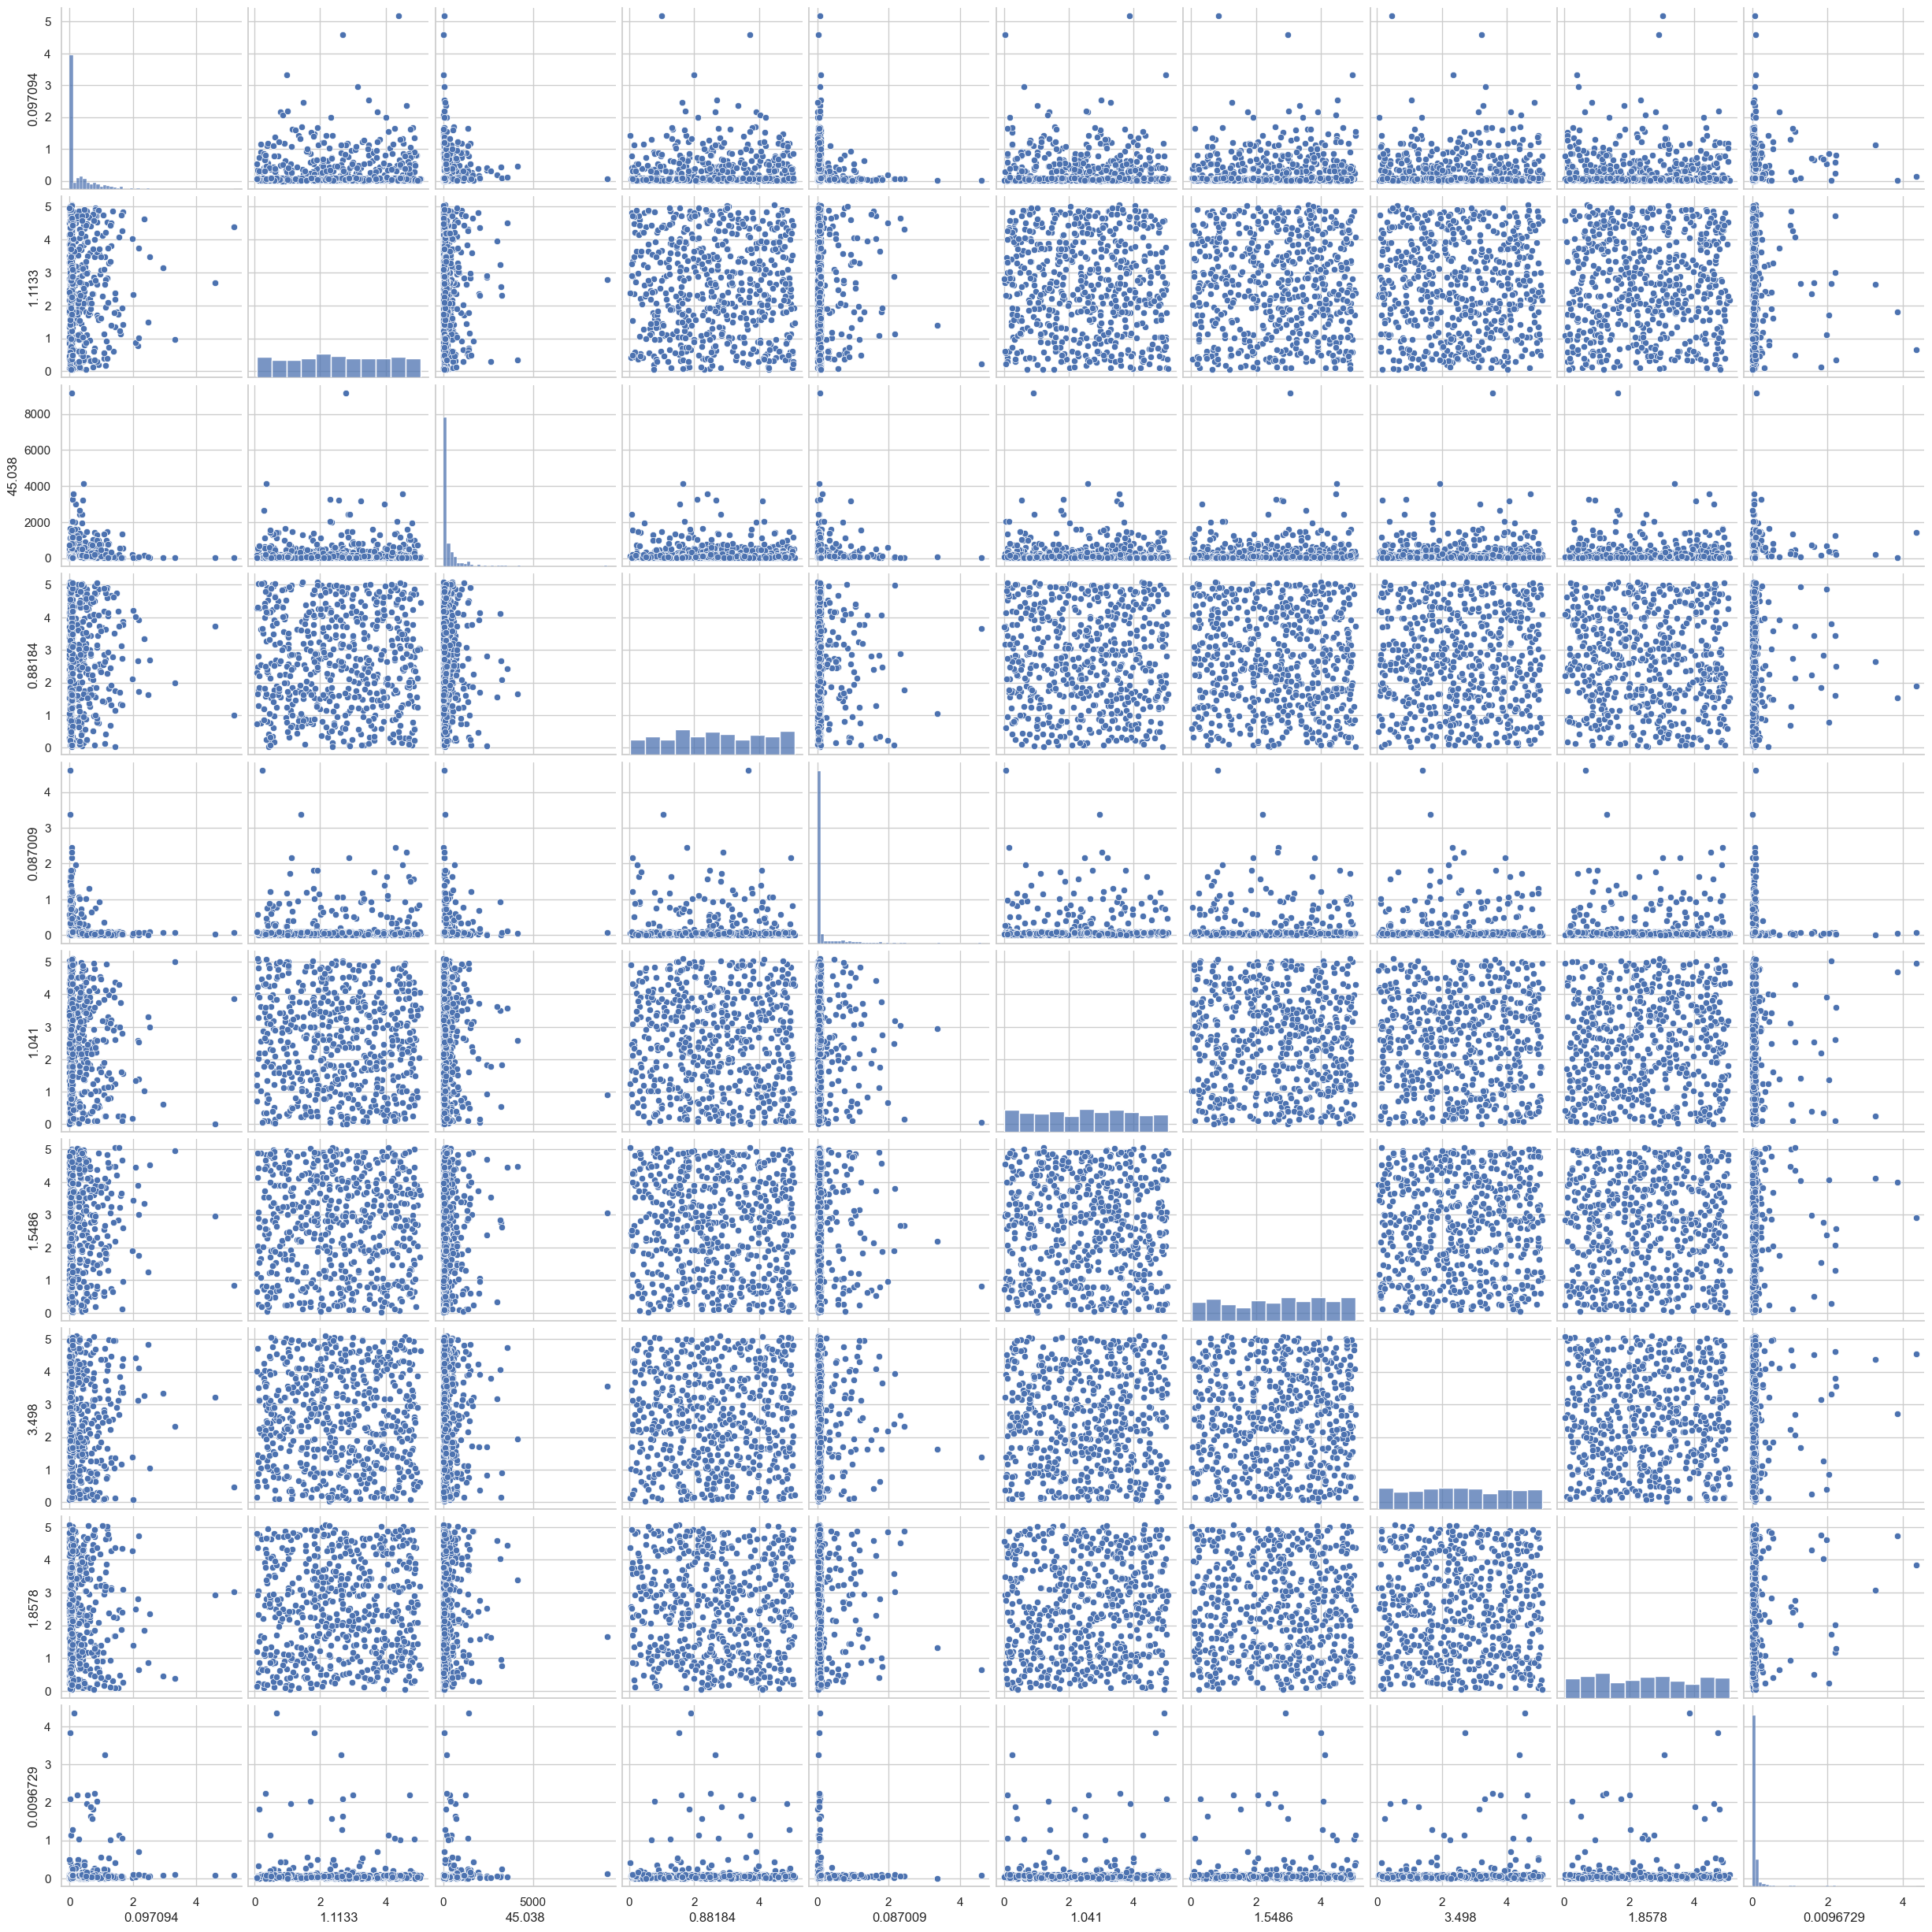

In [44]:
# Missing Value analysis

# 🔍 Check missing values for Training data
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("\n🔹 Missing Values in Training Data:")
display(missing_train)

# 🔍 Check missing values for Test data
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("\n🔹 Missing Values in Test Data:")
display(missing_test)

# 📊 Visualizing missing values (train data)
plt.figure(figsize=(12, 8))
sns.barplot(y=missing_train.index, x=missing_train.values, palette="viridis")
plt.title('Missing Values in Training Data', fontsize=16)
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

# 📊 Visualizing missing values (test data)
plt.figure(figsize=(12, 8))
sns.barplot(y=missing_test.index, x=missing_test.values, palette="magma")
plt.title('Missing Values in Test Data', fontsize=16)
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

plt.figure(figsize=(20,20))
sns.heatmap(train.corr())

sns.pairplot(data=train.iloc[:, :10])

# Fix the data

In [ ]:
X = train
y = train_label['target']




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = HistGradientBoostingRegressor()
model.fit(X_train, y_train)

p = model.predict(X_test)

